# Sprint 3 – Data Cleaning

## Objective

The objective of this sprint is to prepare the dataset for machine learning.

Before building any model, we must identify potential issues such as missing values, duplicate records, incorrect data types, inconsistent values, and outliers.

A clean dataset helps improve model performance and reliability.

# Why Data Cleaning?

Real-world datasets are rarely perfect.

They often contain:

- Missing values
- Duplicate records
- Incorrect values
- Outliers
- Wrong data types
- Inconsistent formatting

Cleaning the data ensures that the machine learning model learns meaningful patterns instead of noise.

In [2]:
# ==========================================
# Sprint 3 - Data Cleaning
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Display Settings 
pd.set_option('display.max_columns',None)

#load Dataset
df = pd.read_csv('../data/ford.csv')

#Create a copy of the original dataset to clean
df_clean= df.copy()

df_clean.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [5]:
print("Original Shape :", df.shape)
print("Working Shape  :", df_clean.shape)

Original Shape : (17966, 9)
Working Shape  : (17966, 9)


In [6]:
missing = df_clean.isnull().sum()

missing

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [7]:
duplicates = df_clean.duplicated().sum()

print(f"Duplicates: {duplicates}")

Duplicates: 154


In [9]:
df_clean.dtypes

model               str
year              int64
price             int64
transmission        str
mileage           int64
fuelType            str
tax               int64
mpg             float64
engineSize      float64
dtype: object

In [12]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
year,17966.0,2016.866470,2.050336,1996.0,2016.0,2017.0,2018.0,2060.0
price,17966.0,12279.534844,4741.343657,495.0,8999.0,11291.0,15299.0,54995.0
mileage,17966.0,23362.608761,19472.054349,1.0,9987.0,18242.5,31060.0,177644.0
tax,17966.0,113.329456,62.012456,0.0,30.0,145.0,145.0,580.0
mpg,17966.0,57.906980,10.125696,20.8,52.3,58.9,65.7,201.8
engineSize,17966.0,1.350807,0.432367,0.0,1.0,1.2,1.5,5.0


In [13]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns
numeric_columns

Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='str')

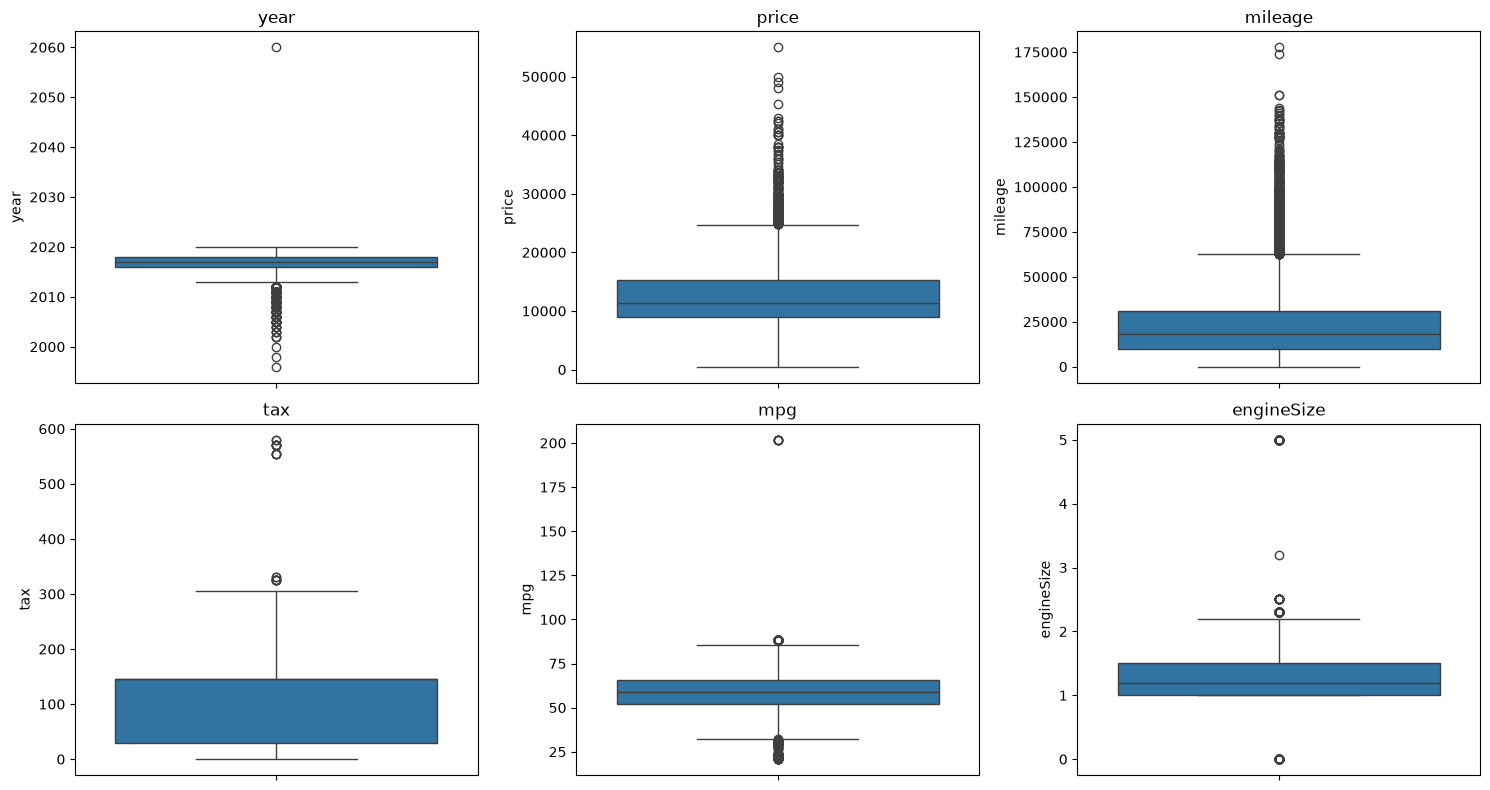

In [20]:
plt.figure(figsize=(15,8))

for i,col in enumerate(numeric_columns):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df_clean[col])
    plt.title(col)

plt.tight_layout()

plt.show()

In [23]:
Q1 = df_clean["price"].quantile(0.25)
Q3 = df_clean["price"].quantile(0.75)

IQR = Q3 - Q1

print(IQR)

6300.0


In [24]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower,upper)

-451.0 24749.0


In [26]:
outliers = df_clean[(df_clean["price"]<lower) | (df_clean["price"]>upper)]

outliers.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
8,Kuga,2019,25500,Automatic,6894,Diesel,145,42.2,2.0
91,Focus,2016,24995,Manual,7997,Petrol,235,36.7,2.3
230,S-MAX,2020,34498,Semi-Auto,4623,Diesel,145,43.5,2.0
302,Mustang,2020,42489,Automatic,3500,Petrol,145,22.1,5.0
339,Mustang,2020,38489,Automatic,3500,Petrol,145,30.7,2.3


In [27]:
outliers_percentage = (len(outliers)/len(df_clean))*100

print(f"Percentage of Outliers: {outliers_percentage:.2f}%")

Percentage of Outliers: 1.59%


# Sprint 3 Summary

Today I learned:

- Why data cleaning is important.
- How to preserve the original dataset.
- How to inspect duplicates and missing values.
- How to identify outliers.
- How the IQR method works.
- Why professional data scientists do not blindly remove outliers.